In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Проверка количества пропусков в каждом столбце
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

C:\Users\Dimi\AppData\Local\Temp\ipykernel_25596\314436920.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Погибли', 'Выжили'])


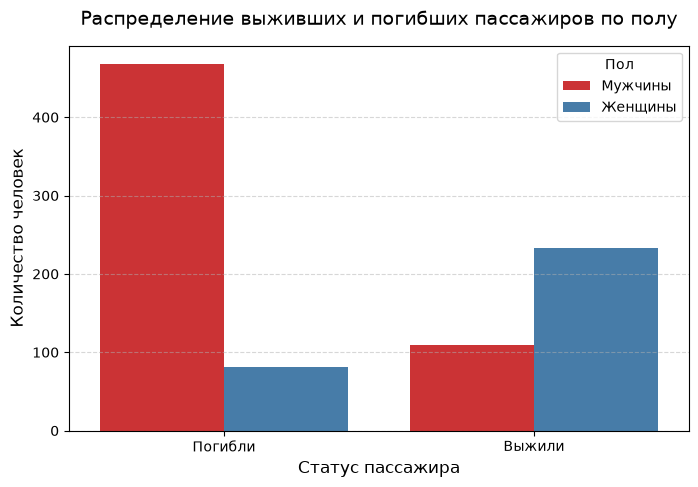

In [23]:
# Распределение выживших в зависимости от пола
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Survived', hue='Sex', palette='Set1')
ax.set_xticklabels(['Погибли', 'Выжили'])

plt.title('Распределение выживших и погибших пассажиров по полу', fontsize=14, pad=15)
plt.xlabel('Статус пассажира', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)

plt.legend(title='Пол', labels=['Мужчины', 'Женщины'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

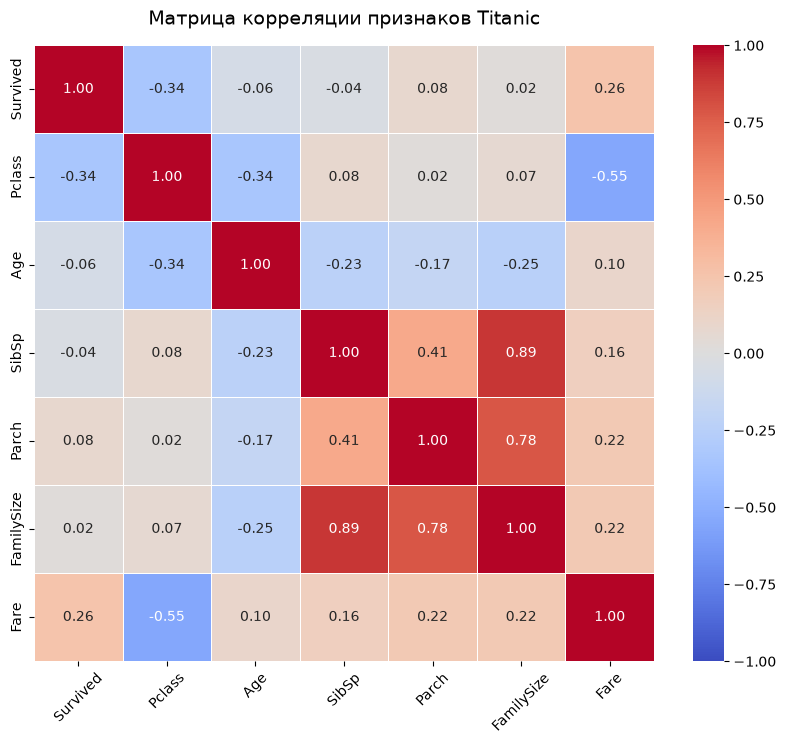

In [ ]:
# FamilySize = SibSp (братья/сестры/супруги) + Parch (родители/дети) + 1 (сам пассажир)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Заполнение пропусков в возрасте медианными значениями
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# Матрица корелляции
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'FamilySize', 'Fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Выводить числовые значения внутри ячеек
    cmap='coolwarm',     # Цветовая гамма (синий — негативная связь, красный — позитивная)
    fmt='.2f',           # Округление чисел до двух знаков после запятой
    linewidths=0.5,      # Зазоры между ячейками
    vmin=-1, vmax=1      # Границы цветовой шкалы от -1 до 1
)

plt.title('Матрица корреляции признаков Titanic', fontsize=14, pad=15)
plt.xticks(rotation=45)  # Поворот подписей по оси X для лучшей читаемости
plt.show()